# Data & libraries

In [1]:
from miRBench.dataset import list_datasets, get_dataset_df
from matplotlib import pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import numpy as np
import numpy.random as rd
from collections import Counter

In [2]:
from src.positional_alignment import pos_aware_align_local, get_posaware_aligner_score, get_posaware_alignments
from src.logreg_analysis import get_params_from_model, encode_posloc_simple
from Bio.Seq import Seq

In [3]:
from statsmodels.discrete.discrete_model import Logit

In [24]:
from time import time

In [4]:
from scipy.optimize import minimize

In [5]:
list_datasets()

['AGO2_CLASH_Hejret2023',
 'AGO2_eCLIP_Klimentova2022',
 'AGO2_eCLIP_Manakov2022']

In [48]:
dset = list_datasets()[2]
train = get_dataset_df(dset, split="train")
test = get_dataset_df(dset, split="test")
train.describe()

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_eCLIP_Manakov2022/train/dataset.tsv
Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_eCLIP_Manakov2022/test/dataset.tsv


,label,start,end,gene_cluster_ID
count,2.516195e+06,2.516195e+06,2.516195e+06,2.516195e+06
mean,4.981013e-01,7.356591e+07,7.356596e+07,2.521657e+05
std,4.999965e-01,5.047086e+07,5.047086e+07,1.841757e+05
min,0.000000e+00,4.700000e+02,5.190000e+02,1.000000e+00
25%,0.000000e+00,3.380269e+07,3.380274e+07,5.914300e+04
50%,0.000000e+00,6.535505e+07,6.535510e+07,2.507970e+05
75%,1.000000e+00,1.081588e+08,1.081588e+08,4.204390e+05
max,1.000000e+00,2.421467e+08,2.421468e+08,5.646200e+05


In [49]:
train_len_select = [len(s)==22 for s in train['noncodingRNA']]
test_len_test = [len(s)==22 for s in test['noncodingRNA']]

In [50]:
train= train.loc[train_len_select]
test = test.loc[test_len_test]

In [51]:
# Based on a simple logistic model from Notebook "Positional logistic regression model on standard SW alignments"
baseline_match_score = 0.724709
baseline_mismatch_score = -0.647892
baseline_gap_score = -0.901264
baseline_alpha = -5.22 

# Gradient descent

In [10]:
def logit_logl(scores_pos, scores_neg, alpha):
    scores_pos = np.array(scores_pos)
    scores_neg = np.array(scores_neg)
    pos_part = np.log(1 + np.exp(-alpha - scores_pos))
    neg_part = np.log(1 + np.exp(alpha + scores_neg))
    return -np.sum(pos_part) - np.sum(neg_part)

In [11]:
def logit_lhood_vect(scores, alpha):
    return 1/(1 + np.exp(-alpha - scores))

In [12]:
def logit_derivative_alpha(scores_pos, scores_neg, alpha):
    pos_part = 1/(1 + np.exp(alpha + scores_pos))
    neg_part = 1/(1 + np.exp(-alpha - scores_neg))
    return np.sum(pos_part) - np.sum(neg_part)

In [13]:
def logit_hess_alpha(scores_pos, scores_neg, alpha):
    pos_part = np.exp(alpha + scores_pos)/(1 + np.exp(alpha + scores_pos))**2
    neg_part = np.exp(-alpha - scores_neg)/(1 + np.exp(-alpha - scores_neg))**2
    return -np.sum(pos_part) - np.sum(neg_part)

In [14]:
def logit_subderivative_theta(scores_pos, scores_neg, X_pos, X_neg, alpha, theta_name):
    pos_part = X_pos[theta_name]/(1 + np.exp(alpha + scores_pos))
    neg_part = X_neg[theta_name]/(1 + np.exp(-alpha - scores_neg))
    return np.sum(pos_part) - np.sum(neg_part)

In [15]:
M = np.zeros((4, 4, 22))   # third coordinate = nt index
for i in range(22):
    M[...,i] = np.eye(4)*(baseline_match_score - baseline_mismatch_score)
    M[..., i] += baseline_mismatch_score
G_miR = np.zeros(21) + baseline_gap_score
G_gene = np.zeros(22) + baseline_gap_score 

In [16]:
alignments_train = get_posaware_alignments(train, M, G_miR, G_gene)

In [17]:
X = encode_posloc_simple(alignments_train)
X.index = train.index

In [18]:
X_pos = X[train['label']==1]
X_neg = X[train['label']==0]

In [19]:
scores_baseline = np.array([x[0] for x in alignments_train])
scores_pos_baseline = scores_baseline[train['label']==1]
scores_neg_baseline = scores_baseline[train['label']==0]

In [21]:
likelihood_pos_baseline = logit_lhood_vect(scores_pos_baseline, baseline_alpha)
likelihood_neg_baseline = logit_lhood_vect(scores_neg_baseline, baseline_alpha)

In [22]:
STEPSIZE = 0.1

In [52]:
# Reset parameters:
M = np.zeros((4, 4, 22))   # third coordinate = nt index
for i in range(22):
    M[...,i] = np.eye(4)*(baseline_match_score - baseline_mismatch_score)
    M[..., i] += baseline_mismatch_score
G_miR = np.zeros(21) + baseline_gap_score
G_gene = np.zeros(22) + baseline_gap_score 
alpha = baseline_alpha

train_scores_aligner = []
test_scores_aligner = []
logit_loglik_values = []
start_time = time()

for iter_nb in range(100):
    print('Iter', iter_nb+1)
    STEP = STEPSIZE / (iter_nb+10)
    alignments_train = get_posaware_alignments(train, M, G_miR, G_gene)
    X_train = encode_posloc_simple(alignments_train)
    X_train.index = train.index
    
    X_pos = X_train[train['label']==1]
    X_neg = X_train[train['label']==0]
    
    scores = np.array([x[0] for x in alignments_train])
    scores_pos = scores[train['label']==1]
    scores_neg = scores[train['label']==0]
    
    # for test score monitoring - optional
    alignments_test = get_posaware_alignments(test, M, G_miR, G_gene)
    X_test = encode_posloc_simple(alignments_test)
    X_test.index = test.index
    scores_test = np.array([x[0] for x in alignments_test])

    # test scores
    l, s = train['label'], scores
    train_scores_aligner.append(average_precision_score(l, s))
    l, s = test['label'], scores_test
    test_scores_aligner.append(average_precision_score(l, s))
    
    curr_log = logit_logl(scores_pos, scores_neg, alpha)
    print('Current loglik, full:', curr_log)
    logit_loglik_values.append(curr_log)
    
    # Select well-fitting observations
    curr_prob_vector_pos = logit_lhood_vect(scores_pos, alpha)
    curr_prob_vector_neg = logit_lhood_vect(scores_neg, alpha)
    pos_q = np.quantile(curr_prob_vector_pos, 0.1)
    neg_q = np.quantile(curr_prob_vector_neg, 0.9)
    
    X_pos_trunc = X_pos[curr_prob_vector_pos>pos_q]
    X_neg_trunc = X_neg[curr_prob_vector_neg<neg_q]
    scores_pos_trunc = scores_pos[curr_prob_vector_pos>pos_q]
    scores_neg_trunc = scores_neg[curr_prob_vector_neg<neg_q]
    curr_log_trunc = logit_logl(scores_pos_trunc, scores_neg_trunc, alpha)
    print('Current loglik, truncated:', curr_log_trunc)

    
    # Step 1: optimizing alpha
    alpha_target = lambda x: -logit_logl(scores_pos_trunc, scores_neg_trunc, x)
    alpha_fprime = lambda x: -logit_derivative_alpha(scores_pos_trunc, scores_neg_trunc, x)
    alpha_fsec = lambda x: -logit_hess_alpha(scores_pos_trunc, scores_neg_trunc, x)
    alpha = minimize(alpha_target, alpha, jac=alpha_fprime, hess=alpha_fsec, method='Newton-CG')['x'][0]
    print("Updated alpha:", alpha)
    
    # Step 2: calculating gradients
    theta_subdiv = {c: logit_subderivative_theta(scores_pos_trunc, 
                                                 scores_neg_trunc, 
                                                 X_pos_trunc, X_neg_trunc, 
                                                 alpha, c) for c in X_train.columns}
    # alpha_div = logit_derivative_alpha(scores_pos, scores_neg, alpha)
    
    # Updating parameters
    # print('alpha gradient:', alpha_div, 'updating by', STEP*alpha_div)
    # alpha += STEP*alpha_div
    for i in range(22):
        print('%i match gradient' % i, theta_subdiv['%i_is_match' % i], 
              'value', M[0,0,i], 'updating by', STEP*theta_subdiv['%i_is_match' % i])
        print('%i mismatch gradient' % i, theta_subdiv['%i_is_mismatch' % i],
              'value', M[0,1,i], 'updating by', STEP*theta_subdiv['%i_is_mismatch' % i])
        M[..., i] += np.eye(4)*STEP*theta_subdiv['%i_is_match' % i]
        M[..., i] += (np.zeros((4, 4)) + 1 - np.eye(4))*STEP*theta_subdiv['%i_is_mismatch' % i]
    print('Gap miR gradient', theta_subdiv['Gap_miR'])
    print('Gap gene gradient', theta_subdiv['Gap_gene'])
    G_miR += STEP*theta_subdiv['Gap_miR']
    G_gene += STEP*theta_subdiv['Gap_gene']
end_time = time()
sbgd_time = end_time-start_time

Iter 1
Current loglik, full: -622335.8979332431
Current loglik, truncated: -439888.63690785074
Updated alpha: -4.91132813838808
0 match gradient 10380.988334010945 value 0.7247089999999999 updating by 103.80988334010945
0 mismatch gradient 0.0 value -0.647892 updating by 0.0
1 match gradient 30729.321938042063 value 0.7247089999999999 updating by 307.2932193804206
1 mismatch gradient 110.03909960490819 value -0.647892 updating by 1.1003909960490819
2 match gradient 32849.803430400076 value 0.7247089999999999 updating by 328.4980343040008
2 mismatch gradient -2164.8153966536056 value -0.647892 updating by -21.648153966536057
3 match gradient 30004.154530076834 value 0.7247089999999999 updating by 300.04154530076835
3 mismatch gradient -2973.8522384860225 value -0.647892 updating by -29.738522384860225
4 match gradient 26899.29985440262 value 0.7247089999999999 updating by 268.9929985440262
4 mismatch gradient -3225.036849239352 value -0.647892 updating by -32.25036849239352
5 match grad

/tmp/ipykernel_40036/1471809109.py:5: RuntimeWarning: overflow encountered in exp
  neg_part = np.log(1 + np.exp(alpha + scores_neg))


Current loglik, full: -inf
Current loglik, truncated: -0.0
Updated alpha: -4.91132813838808
0 match gradient 0.0 value 104.53459234010946 updating by 0.0
0 mismatch gradient 0.0 value -0.647892 updating by 0.0
1 match gradient 0.0 value 308.01792838042064 updating by 0.0
1 mismatch gradient 0.0 value 0.45249899604908184 updating by 0.0
2 match gradient 0.0 value 329.2227433040008 updating by 0.0
2 mismatch gradient 0.0 value -22.296045966536056 updating by 0.0
3 match gradient 0.0 value 300.76625430076837 updating by 0.0
3 mismatch gradient 0.0 value -30.386414384860224 updating by 0.0
4 match gradient 0.0 value 269.7177075440262 updating by 0.0
4 mismatch gradient 0.0 value -32.89826049239352 updating by 0.0
5 match gradient 0.0 value 257.5875367740945 updating by 0.0
5 mismatch gradient 0.0 value -51.21819841959825 updating by 0.0
6 match gradient 0.0 value 193.81088951161888 updating by 0.0
6 mismatch gradient 0.0 value -36.418010747971955 updating by 0.0
7 match gradient 0.0 value 

KeyboardInterrupt: 

In [47]:
print('Full training time on',dset, '22nt miRs', train.shape[0], 'rows:' sbgd_time, 'seconds')

Full training time on AGO2_CLASH_Hejret2023 36.95296239852905 seconds


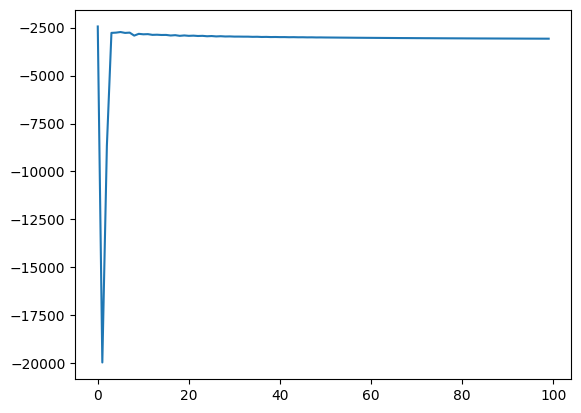

In [34]:
plt.figure()
plt.plot(logit_loglik_values)

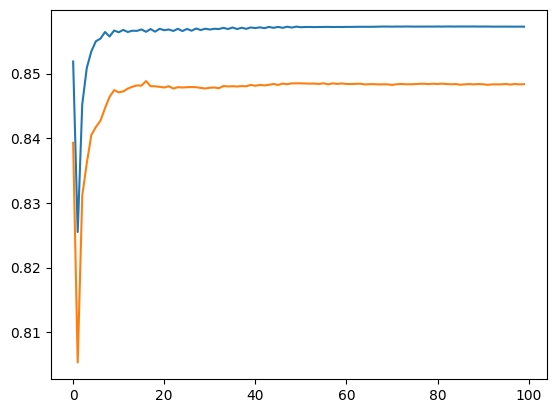

In [35]:
plt.figure()
plt.plot(train_scores_aligner)
plt.plot(test_scores_aligner)

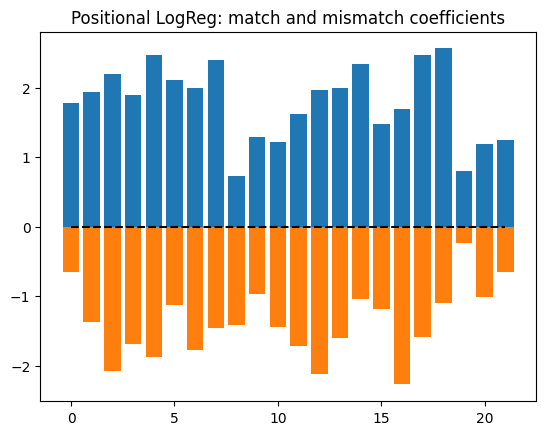

In [36]:
plt.figure()
plt.title('Positional LogReg: match and mismatch coefficients')
plt.bar(np.arange(22), M[0, 0, ...])
plt.bar(np.arange(22), M[0, 1, ...])
plt.plot([0, 21], [0, 0], 'k--')

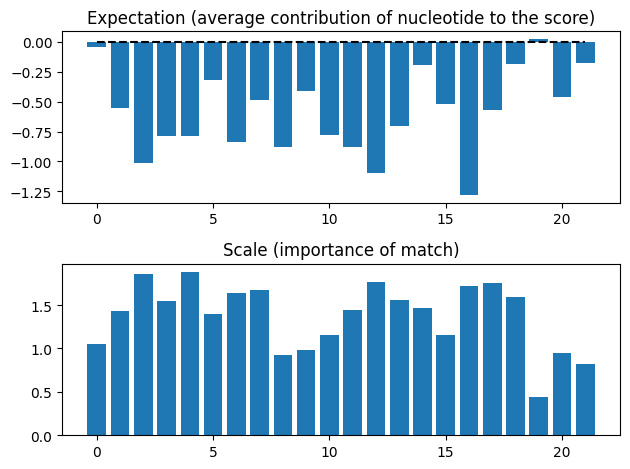

In [37]:
plt.figure()
plt.subplot(211)
plt.title('Expectation (average contribution of nucleotide to the score)')
plt.bar(np.arange(22), np.mean(M, axis=(0,1)))
plt.plot([0, 21], [0, 0], 'k--')
plt.subplot(212)
plt.title('Scale (importance of match)')
plt.bar(np.arange(22), np.std(M, axis=(0,1)))
plt.tight_layout()

In [51]:
M[...,0]

array([[ 1.74614681, -0.647892  , -0.647892  , -0.647892  ],
       [-0.647892  ,  1.74614681, -0.647892  , -0.647892  ],
       [-0.647892  , -0.647892  ,  1.74614681, -0.647892  ],
       [-0.647892  , -0.647892  , -0.647892  ,  1.74614681]])

In [52]:
M[...,2]

array([[ 1.92327276, -2.05424129, -2.05424129, -2.05424129],
       [-2.05424129,  1.92327276, -2.05424129, -2.05424129],
       [-2.05424129, -2.05424129,  1.92327276, -2.05424129],
       [-2.05424129, -2.05424129, -2.05424129,  1.92327276]])

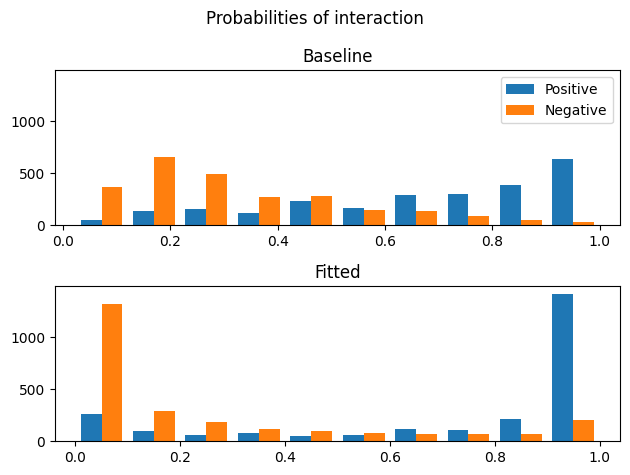

In [38]:
plt.subplots(2, 1, sharey=True)
plt.suptitle('Probabilities of interaction')
plt.subplot(211)
plt.title('Baseline')
plt.hist([likelihood_pos_baseline, likelihood_neg_baseline]) 
plt.legend(['Positive', 'Negative'])

plt.subplot(212)
plt.title('Fitted')
plt.hist([curr_prob_vector_pos, curr_prob_vector_neg])
plt.tight_layout()

In [39]:
likelihood_pos = logit_lhood_vect(scores_test[test['label']==1], alpha)
likelihood_neg = logit_lhood_vect(scores_test[test['label']==0], alpha)

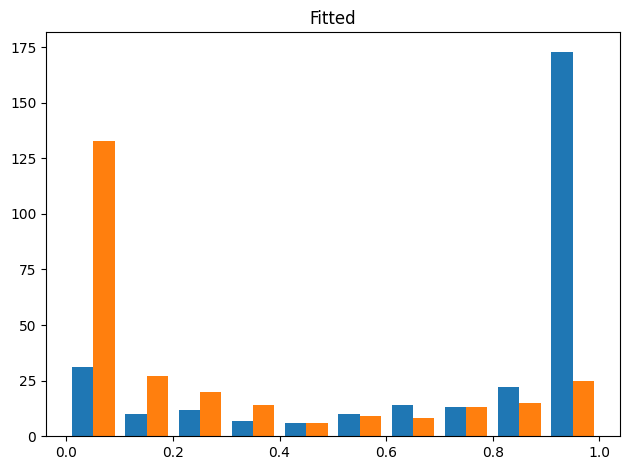

In [40]:
plt.figure()

plt.title('Fitted')
plt.hist([likelihood_pos, likelihood_neg])
plt.tight_layout()

Average precision: 0.8483756867062837


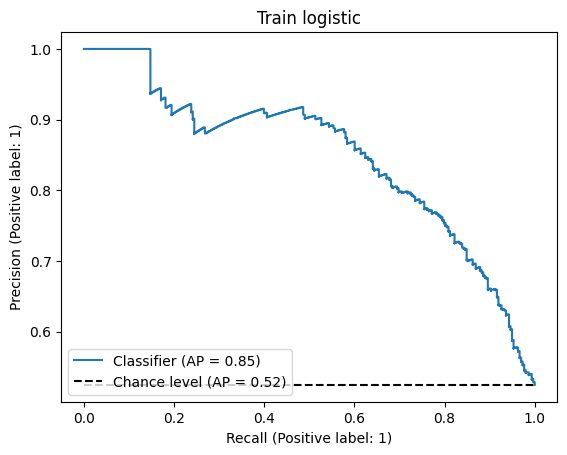

In [41]:
l, s = [0]*len(likelihood_neg) + [1]*len(likelihood_pos), np.hstack((likelihood_neg, likelihood_pos))
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

In [42]:
print(get_posaware_aligner_score(M, G_miR, G_gene, train))

0.8572682860499066


In [43]:
print(get_posaware_aligner_score(M, G_miR, G_gene, test))

0.8483712391902362


In [44]:
alignments_train = get_posaware_alignments(train, M, G_miR, G_gene)
alignments_test = get_posaware_alignments(test, M, G_miR, G_gene)

In [45]:
X_train = encode_posloc_simple(alignments_train)
X_train.index = train.index
X_test = encode_posloc_simple(alignments_test)
X_test.index = test.index

In [62]:
[c for c in X_train.columns if sum(X_train[c]) == 0]

['0_is_mismatch', '21_is_mismatch']

In [63]:
# cols_to_drop = ['0_is_mismatch', '21_is_mismatch']
cols_to_drop = ['0_is_mismatch', '21_is_mismatch']
X_test.drop(cols_to_drop, axis=1, inplace=True)
X_train.drop(cols_to_drop, axis=1, inplace=True)

In [69]:
refitted_positional_logit_machine = Logit(endog = train['label'], exog=X_train)

In [70]:
# refitted_positional_logit=refitted_positional_logit_machine.fit_regularized(alpha=5)
refitted_positional_logit=refitted_positional_logit_machine.fit()

Optimization terminated successfully.
         Current function value: 0.478292
         Iterations 7


In [71]:
refitted_positional_logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  label   No. Observations:                 4980
Model:                          Logit   Df Residuals:                     4935
Method:                           MLE   Df Model:                           44
Date:                Mon, 13 Oct 2025   Pseudo R-squ.:                  0.3100
Time:                        19:41:04   Log-Likelihood:                -2381.9
converged:                       True   LL-Null:                       -3451.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
0_is_match         0.7254      0.120      6.029      0.000       0.490       0.961
1_is_match         0.9248      0.129      7.143      0.000       0.671       1.179
1_is_mismatch     -0.5899      0.235     -2.513      0.012      -1.050      -0.130
2_is_match         0.8116      0.125      6.487      0.000       0.566       1.057
2_is_mismatch     -0.8567      0.272     -3.154      0.002      -1.389      -0.324
3_is_match         0.8047      0.115      6.973      0.000       0.579       1.031
3_is_mismatch     -0.9033      0.174     -5.194      0.000      -1.244      -0.562
4_is_match         1.0426      0.129      8.075      0.000       0.790       1.296
4_is_mismatch     -0.5605      0.196     -2.858      0.004      -0.945      -0.176
5_is_match         0.8044      0.117      6.871      0.000       0.575       1.034
5_is_mismatch     -0.5921      0.146     -4.065      0.000      -0.878      -0.307
6_is_match         0.7923      0.111      7.118      0.000       0.574       1.010
6_is_mismatch     -0.7943      0.162     -4.899      0.000      -1.112      -0.476
7_is_match         1.0204      0.135      7.543      0.000       0.755       1.285
7_is_mismatch     -0.5268      0.173     -3.053      0.002      -0.865      -0.189
8_is_match         0.2728      0.100      2.738      0.006       0.078       0.468
8_is_mismatch     -0.7681      0.127     -6.065      0.000      -1.016      -0.520
9_is_match         0.7126      0.134      5.315      0.000       0.450       0.975
9_is_mismatch     -0.3860      0.149     -2.592      0.010      -0.678      -0.094
10_is_match        0.5439      0.117      4.649      0.000       0.315       0.773
10_is_mismatch    -0.5633      0.137     -4.115      0.000      -0.832      -0.295
11_is_match        0.6563      0.107      6.111      0.000       0.446       0.867
11_is_mismatch    -0.9051      0.151     -6.010      0.000      -1.200      -0.610
12_is_match        0.7533      0.110      6.828      0.000       0.537       0.969
12_is_mismatch    -1.0834      0.172     -6.312      0.000      -1.420      -0.747
13_is_match        0.8464      0.125      6.766      0.000       0.601       1.092
13_is_mismatch    -0.9427      0.169     -5.562      0.000      -1.275      -0.611
14_is_match        0.8271      0.117      7.039      0.000       0.597       1.057
14_is_mismatch    -0.5836      0.161     -3.626      0.000      -0.899      -0.268
15_is_match        0.4755      0.114      4.175      0.000       0.252       0.699
15_is_mismatch    -0.5787      0.128     -4.537      0.000      -0.829      -0.329
16_is_match        0.7913      0.126      6.288      0.000       0.545       1.038
16_is_mismatch    -1.0233      0.204     -5.027      0.000      -1.422      -0.624
17_is_match        1.0791      0.156      6.932      0.000       0.774       1.384
17_is_mismatch    -0.7200      0.212     -3.404      0.001      -1.135      -0.305
18_is_match        1.2213      0.149      8.201      0.000       0.929       1.513
18_i

Average precision: 0.8594366753415721


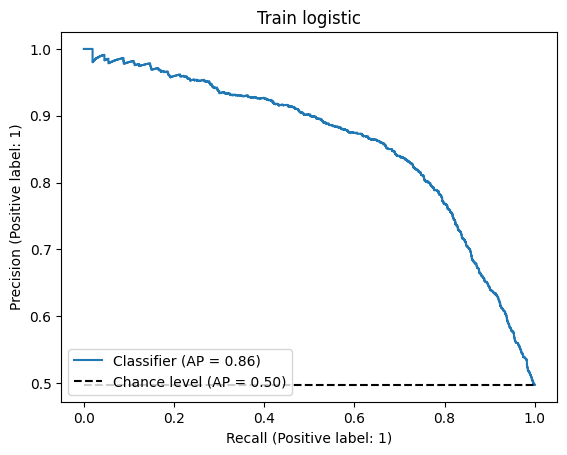

In [72]:
l, s = train['label'], refitted_positional_logit.predict()
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

Average precision: 0.8496512709330399


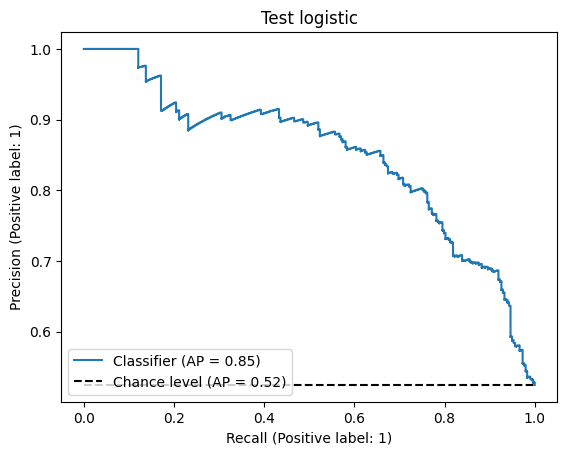

In [73]:
l, s = test['label'], refitted_positional_logit.predict(X_test)
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Test logistic')
print('Average precision:', average_precision_score(l, s))

Manakov validation:

In [90]:
manakov_lo = get_dataset_df(list_datasets()[2], split="leftout")
manakov_lo.describe()

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_eCLIP_Manakov2022/leftout/dataset.tsv


,label,start,end,gene_cluster_ID
count,20054.000000,2.005400e+04,2.005400e+04,20054.000000
mean,0.500000,7.777583e+07,7.777588e+07,4527.216216
std,0.500012,5.656789e+07,5.656789e+07,2574.098725
min,0.000000,4.960000e+02,5.450000e+02,1.000000
25%,0.000000,3.283980e+07,3.283985e+07,2304.000000
50%,0.500000,6.680742e+07,6.680747e+07,4584.500000
75%,1.000000,1.130310e+08,1.130311e+08,6749.000000
max,1.000000,2.473332e+08,2.473333e+08,8808.000000


In [91]:
manakov_lo_len_select = [len(s)==22 for s in manakov_lo['noncodingRNA']]
manakov_lo = manakov_lo.loc[manakov_lo_len_select]

In [92]:
alignments_manakov_lo = get_posaware_alignments(manakov_lo, M, G_miR, G_gene)

In [100]:
scores_manakov = np.array([x[0] for x in alignments_manakov_lo])
probs_manakov = logit_lhood_vect(scores_manakov, alpha)

Average precision: 0.7569860937847034


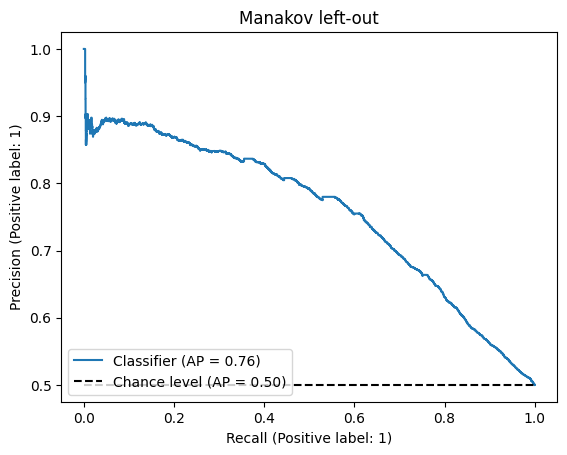

In [101]:
l, s = manakov_lo['label'], probs_manakov
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Manakov left-out')
print('Average precision:', average_precision_score(l, s))

Text(0.5, 1.0, 'Scores on Manakov left-out')

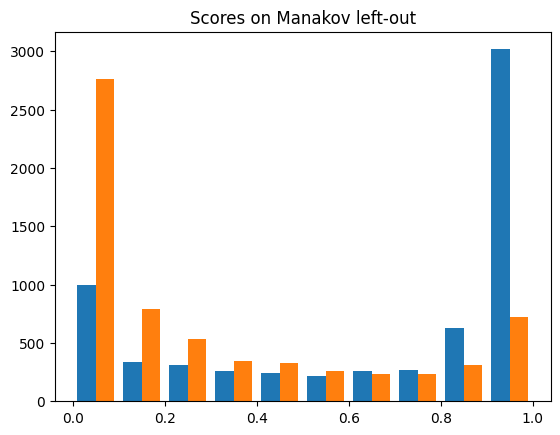

In [110]:
plt.figure()
plt.hist([probs_manakov[manakov_lo['label']==1], probs_manakov[manakov_lo['label']==0]])
plt.title('Scores on Manakov left-out')

In [105]:
X_manakov_lo = encode_posloc_simple(alignments_manakov_lo)
X_manakov_lo.index = manakov_lo.index
# cols_to_drop = ['0_is_mismatch', '21_is_mismatch']
cols_to_drop = ['0_is_mismatch', '21_is_mismatch']
X_manakov_lo.drop(cols_to_drop, axis=1, inplace=True)

In [106]:
manakov_logit_machine = Logit(endog = manakov_lo['label'], exog=X_manakov_lo)
manakov_logit=manakov_logit_machine.fit()
manakov_refitted_scores = manakov_logit.predict()

Optimization terminated successfully.
         Current function value: 0.561827
         Iterations 6


Text(0.5, 1.0, 'After fitting a logistic regression on alignments')

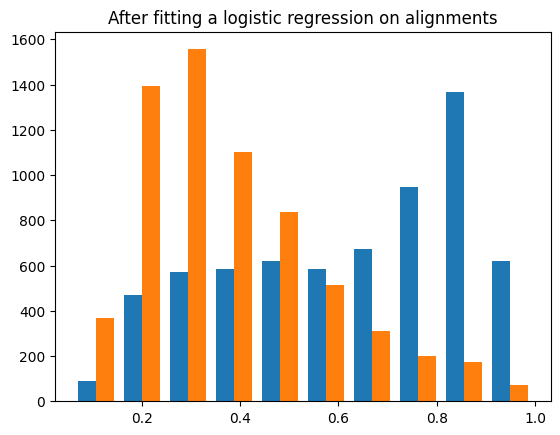

In [109]:
plt.figure()
plt.hist([manakov_refitted_scores[manakov_lo['label']==1], manakov_refitted_scores[manakov_lo['label']==0]])
plt.title('After fitting a logistic regression on alignments')

# Semismooth Newton method

Results after fitting:

Average match score: 1.9995287339693606  
Average mismatch score: -2.048547600811088  
miR gap score: -3.606706671713618  
Gene gap score: -2.8425890275402486  

We have overfitting. May need L2 regularization with reference values obtained by logistic fitting to match/mismatch/miRgap/genegap counts. This has only 4 parameters so will be estimated nicely.   

miRNA nt 18 has a positive mismatch weights, interesting but likely overfit.  

In [53]:
def logit_subhessian_theta(scores_pos, scores_neg, X_pos, X_neg, alpha, theta1_name, theta2_name):
    pos_part = X_pos[theta1_name]*X_pos[theta2_name]*np.exp(alpha + scores_pos)/(1 + np.exp(alpha + scores_pos))**2
    neg_part = X_neg[theta1_name]*X_neg[theta2_name]*np.exp(-alpha - scores_neg)/(1 + np.exp(-alpha - scores_neg))**2
    return -np.sum(pos_part) - np.sum(neg_part)

In [54]:
# Reset parameters:
M = np.zeros((4, 4, 22))   # third coordinate = nt index
for i in range(22):
    M[...,i] = np.eye(4)*(baseline_match_score - baseline_mismatch_score)
    M[..., i] += baseline_mismatch_score
G_miR = np.zeros(21) + baseline_gap_score
G_gene = np.zeros(22) + baseline_gap_score 
alpha = baseline_alpha

train_scores_aligner = []
test_scores_aligner = []
logit_loglik_values = []

LBD = 1e-06

for iter_nb in range(100):
    print('Iter', iter_nb+1)
    alignments_train = get_posaware_alignments(train, M, G_miR, G_gene)
    X_train = encode_posloc_simple(alignments_train)
    X_train.drop(['intercept'], axis=1, inplace=True)
    X_train.index = train.index
    column_map = {c: i for i, c in enumerate(X_train.columns)} 
    
    X_pos = X_train[train['label']==1]
    X_neg = X_train[train['label']==0]
    
    scores = np.array([x[0] for x in alignments_train])
    scores_pos = scores[train['label']==1]
    scores_neg = scores[train['label']==0]
    
    # for test score monitoring - optional
    alignments_test = get_posaware_alignments(test, M, G_miR, G_gene)
    #X_test = encode_posloc_simple(alignments_test)
    #X_test.index = test.index
    scores_test = np.array([x[0] for x in alignments_test])

    # test scores
    l, s = train['label'], scores
    train_scores_aligner.append(average_precision_score(l, s))
    l, s = test['label'], scores_test
    test_scores_aligner.append(average_precision_score(l, s))
    
    curr_log = logit_logl(scores_pos, scores_neg, alpha)
    print('Current loglik, full:', curr_log)
    logit_loglik_values.append(curr_log)
    
    # Select well-fitting observations
    curr_prob_vector_pos = logit_lhood_vect(scores_pos, alpha)
    curr_prob_vector_neg = logit_lhood_vect(scores_neg, alpha)
    pos_q = np.quantile(curr_prob_vector_pos, 0.1)
    neg_q = np.quantile(curr_prob_vector_neg, 0.9)
    
    X_pos_trunc = X_pos[curr_prob_vector_pos>pos_q]
    X_neg_trunc = X_neg[curr_prob_vector_neg<neg_q]
    scores_pos_trunc = scores_pos[curr_prob_vector_pos>pos_q]
    scores_neg_trunc = scores_neg[curr_prob_vector_neg<neg_q]
    curr_log_trunc = logit_logl(scores_pos_trunc, scores_neg_trunc, alpha)
    print('Current loglik, truncated:', curr_log_trunc)

    
    # Step 1: optimizing alpha
    alpha_target = lambda x: -logit_logl(scores_pos_trunc, scores_neg_trunc, x)
    alpha_fprime = lambda x: -logit_derivative_alpha(scores_pos_trunc, scores_neg_trunc, x)
    alpha_fsec = lambda x: -logit_hess_alpha(scores_pos_trunc, scores_neg_trunc, x)
    alpha = minimize(alpha_target, alpha, jac=alpha_fprime, hess=alpha_fsec, method='Newton-CG')['x'][0]
    print("Updated alpha:", alpha)
    
    # Step 2: calculating gradients
    theta_subdiv = [logit_subderivative_theta(scores_pos_trunc, 
                                              scores_neg_trunc, 
                                              X_pos_trunc, X_neg_trunc, 
                                              alpha, c) for c in column_map]
    theta_subhess = [[logit_subhessian_theta(scores_pos_trunc, 
                                             scores_neg_trunc, 
                                             X_pos_trunc, X_neg_trunc, 
                                             alpha, c1, c2) for c1 in column_map] for c2 in column_map]
    theta_subhess = np.array(theta_subhess)
    ##  Moore–Penrose pseudoinverse
    step, *_ = np.linalg.lstsq(theta_subhess, theta_subdiv, rcond=None)
    step *= -1
    
    ## Levenberg–Marquardt regularization
    # theta_subhess += np.eye(len(column_map))*LBD 
    # step = -np.linalg.solve(theta_subhess, theta_subdiv)
    
    for i in range(22):
        match_col_id = column_map['%i_is_match' % i]
        match_step = step[match_col_id]
        print('%i match gradient' % i, theta_subdiv[match_col_id], 
              'value', M[0,0,i], 'updating by', match_step)
        if i == 0 or i == 21:
            mismatch_step = 0
            print('%i mismatch skipped' % i)
        else:
            mismatch_col_id = column_map['%i_is_mismatch' % i]
            mismatch_step = step[mismatch_col_id]
            print('%i mismatch gradient' % i, theta_subdiv[mismatch_col_id],
              'value', M[0,1,i], 'updating by', mismatch_step)
        M[..., i] += np.eye(4)*match_step
        M[..., i] += (np.zeros((4, 4)) + 1 - np.eye(4))*mismatch_step
    mirgap_col_id = column_map['Gap_miR']
    genegap_col_id = column_map['Gap_gene']
    print('Gap miR gradient', theta_subdiv[mirgap_col_id], 'value', G_miR[0], 'update by', step[mirgap_col_id])
    print('Gap gene gradient', theta_subdiv[genegap_col_id], 'value', G_gene[0], 'update by', step[genegap_col_id])
    G_miR += step[mirgap_col_id]
    G_gene += step[genegap_col_id]
    

Iter 1
Current loglik, full: -622335.8979332431
Current loglik, truncated: -439888.63690785074
Updated alpha: -4.91132813838808
0 match gradient 10380.988334010945 value 0.7247089999999999 updating by -0.14314223738953405
0 mismatch skipped
1 match gradient 30729.321938042063 value 0.7247089999999999 updating by 0.4748930877714174
1 mismatch gradient 110.03909960490819 value -0.647892 updating by 0.16765222229299112
2 match gradient 32849.803430400076 value 0.7247089999999999 updating by 0.2809357640171343
2 mismatch gradient -2164.8153966536056 value -0.647892 updating by -0.3695160484855983
3 match gradient 30004.154530076834 value 0.7247089999999999 updating by 0.14576290140714593
3 mismatch gradient -2973.8522384860225 value -0.647892 updating by -0.46926272964986854
4 match gradient 26899.29985440262 value 0.7247089999999999 updating by 0.1347172489608026
4 mismatch gradient -3225.036849239352 value -0.647892 updating by -0.42080168209585256
5 match gradient 25686.282777409448 val

Current loglik, full: -569827.8609822765
Current loglik, truncated: -384393.65859767573
Updated alpha: -5.2847607753601835
0 match gradient 1950.7149461881127 value 0.5547305361687571 updating by -0.11695998221370783
0 mismatch skipped
1 match gradient 12877.328577482112 value 1.3248768499810826 updating by 0.20600310857683043
1 mismatch gradient 117.14815508086213 value -0.5446641333063873 updating by 0.08897615341253469
2 match gradient 13713.829682319294 value 1.0646231525781125 updating by 0.05799068868583025
2 mismatch gradient 14.912320822260426 value -1.3426809200005876 updating by -0.09602836599127729
3 match gradient 13499.063714172982 value 0.8483514307718193 updating by 0.017472172461568562
3 mismatch gradient -168.77295003336212 value -1.5532111750008613 updating by -0.2428080066510354
4 match gradient 12510.280606052402 value 1.0231788457720934 updating by -0.09527267043569622
4 mismatch gradient -19.620011602979503 value -1.2272200689658181 updating by -0.314445908314967


Current loglik, full: -564913.4510521397
Current loglik, truncated: -372247.54604438617
Updated alpha: -5.527157012298164
0 match gradient 2685.899454247872 value 0.360887367858432 updating by -0.02102532618402981
0 mismatch skipped
1 match gradient 9304.319388059783 value 1.658521733226452 updating by 0.1216903172756102
1 mismatch gradient 0.0 value -0.45568797989385174 updating by -8.326672684688674e-17
2 match gradient 10325.411318727332 value 1.1157294886730145 updating by 0.06041313999329319
2 mismatch gradient 58.45724263466332 value -1.6997594136833978 updating by -0.06592626976942187
3 match gradient 9169.93702905855 value 0.8256393391316569 updating by -0.137302759691251
3 mismatch gradient 79.20401591866903 value -2.000689913680126 updating by -0.31582404793812224
4 match gradient 11336.933710463374 value 1.0347197689010201 updating by 0.10551551402230604
4 mismatch gradient 1147.072480034859 value -1.4065003066233874 updating by 0.0663727641973689
5 match gradient 11573.3216

Current loglik, full: -564757.6385858876
Current loglik, truncated: -364948.2580527824
Updated alpha: -5.748280803926495
0 match gradient 2839.8161359583537 value 0.3419374284579117 updating by 0.01984288181182425
0 mismatch skipped
1 match gradient 7363.211116804625 value 1.7503695132247656 updating by 0.016817426277050938
1 mismatch gradient 0.0 value -0.45568797989384685 updating by -1.8041124150158794e-15
2 match gradient 9040.758649745665 value 1.2923744026813786 updating by 0.13201155797144482
2 mismatch gradient 176.15784197187122 value -1.8823866119268853 updating by 0.14786976250008924
3 match gradient 8508.12724022071 value 0.6758559596872908 updating by -0.09393703843644781
3 mismatch gradient 256.6751153041937 value -2.4713226058413538 updating by -0.17121263174570797
4 match gradient 10191.325917740221 value 1.1898291603306934 updating by 0.09892046754108838
4 mismatch gradient 633.4420371545375 value -1.36725052745046 updating by 0.01930298099434842
5 match gradient 9045.

KeyboardInterrupt: 

LM regularized:  
Iter 20
Current loglik, full: -2509.239350478537
Current loglik, truncated: -1240.8824274641293
    
Iter 30
Current loglik, full: -2598.480083070689
Current loglik, truncated: -1191.1612248107203
    
PM pseudoinverse:   

Iter 20
Current loglik, full: -2509.2307390199826
Current loglik, truncated: -1240.8877030054937

Iter 30
Current loglik, full: -2598.4694815087214
Current loglik, truncated: -1191.1646575478076

Iter 50
Current loglik, full: -2771.0162721325505
Current loglik, truncated: -1133.936819084367

Iter 80
Current loglik, full: -2960.3024673602404
Current loglik, truncated: -1101.8877744859765


Iter 100
Current loglik, full: -3119.334520025095
Current loglik, truncated: -1090.198478434059

NOTE: 
Iter 91
Current loglik, full: -3038.6415914226554
Current loglik, truncated: -1086.6369722165427 <--- !!!!!!


SbGD:
Iter 20
Current loglik, full: -2921.608315170719
Current loglik, truncated: -1161.4505797934487

Iter 30
Current loglik, full: -2972.4613942116807
Current loglik, truncated: -1150.2146842972643

Iter 50
Current loglik, full: -3016.774037306869
Current loglik, truncated: -1144.4174069651162

Iter 80
Current loglik, full: -3050.80758225688
Current loglik, truncated: -1138.6297724594597

Iter 100
Current loglik, full: -3063.8114653096773
Current loglik, truncated: -1136.0831613451728

Start with SbGD for a rapid start; when target increases switch to PM pseudoinverse for robust convergence; when target increases switch to LM regularization for numerical stability

In [39]:
H = np.array(theta_subhess)
H.shape

(46, 46)

In [32]:
np.linalg.matrix_rank(H)

42

In [40]:
H

array([[ -79.05041996,   -0.        ,  -70.76553483, ...,   -0.        ,
         -36.31835113,  -84.76694231],
       [  -0.        ,   -0.        ,   -0.        , ...,   -0.        ,
          -0.        ,   -0.        ],
       [ -70.76553483,   -0.        , -129.78129224, ...,   -0.        ,
         -56.88620675, -129.47792403],
       ...,
       [  -0.        ,   -0.        ,   -0.        , ...,   -0.        ,
          -0.        ,   -0.        ],
       [ -36.31835113,   -0.        ,  -56.88620675, ...,   -0.        ,
        -209.71605269, -120.82108297],
       [ -84.76694231,   -0.        , -129.47792403, ...,   -0.        ,
        -120.82108297, -769.10818692]])

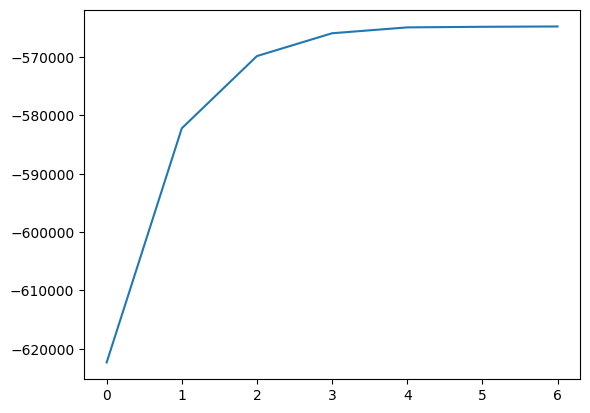

In [55]:
plt.figure()
plt.plot(logit_loglik_values)

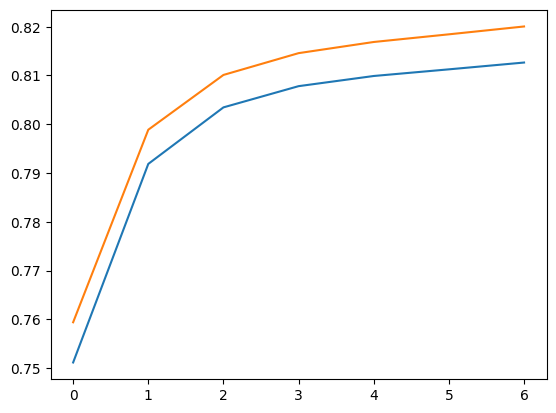

In [56]:
plt.figure()
plt.plot(train_scores_aligner)
plt.plot(test_scores_aligner)

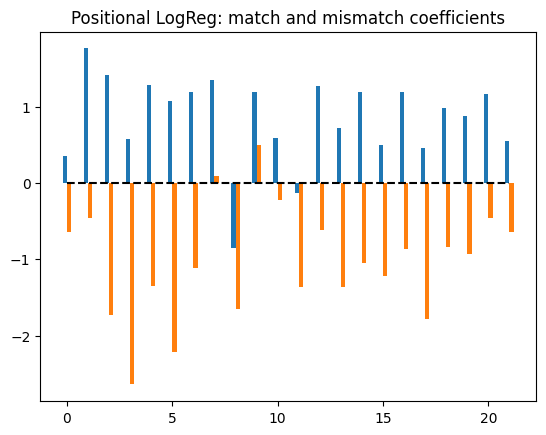

In [74]:
plt.figure()
plt.title('Positional LogReg: match and mismatch coefficients')
plt.bar(np.arange(22)-0.1, M[0, 0, ...], width=0.2)
plt.bar(np.arange(22)+0.1, M[0, 1, ...], width=0.2)
plt.plot([0, 21], [0, 0], 'k--')

In [58]:
print('Average match score:', np.mean(M[0, 0, ...]))
print('Average mismatch score:', np.mean(M[0, 1, ...]))
print('miR gap score:', G_miR[0])
print('Gene gap score:', G_gene[0])

Average match score: 0.8541067185584604
Average mismatch score: -1.0264630474145018
miR gap score: -1.4635482855663797
Gene gap score: -2.0076186806788847


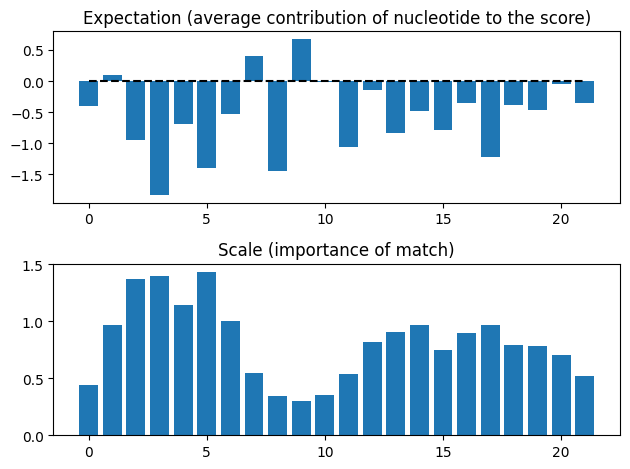

In [59]:
plt.figure()
plt.subplot(211)
plt.title('Expectation (average contribution of nucleotide to the score)')
plt.bar(np.arange(22), np.mean(M, axis=(0,1)))
plt.plot([0, 21], [0, 0], 'k--')
plt.subplot(212)
plt.title('Scale (importance of match)')
plt.bar(np.arange(22), np.std(M, axis=(0,1)))
plt.tight_layout()

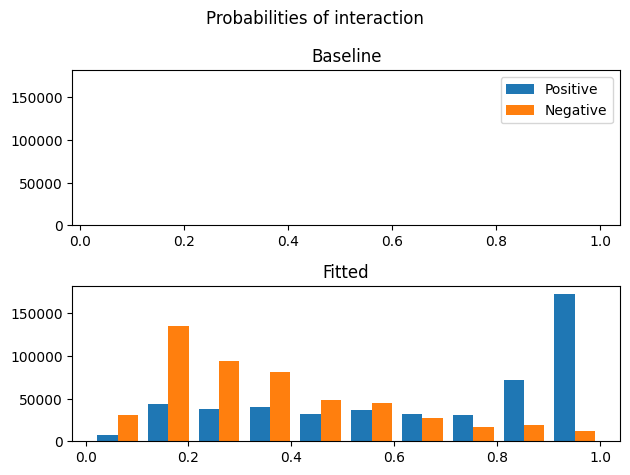

In [61]:
plt.subplots(2, 1, sharey=True)
plt.suptitle('Probabilities of interaction')
plt.subplot(211)
plt.title('Baseline')
plt.hist([likelihood_pos_baseline, likelihood_neg_baseline]) 
plt.legend(['Positive', 'Negative'])

plt.subplot(212)
plt.title('Fitted')
plt.hist([curr_prob_vector_pos, curr_prob_vector_neg])
plt.tight_layout()

Average precision: 0.8126515049588035


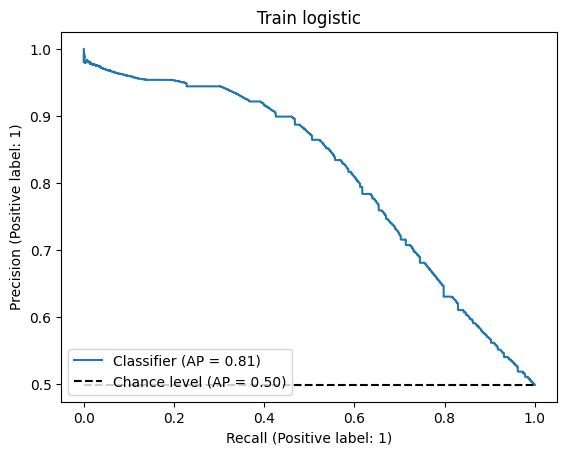

In [62]:
l, s = [0]*len(curr_prob_vector_neg) + [1]*len(curr_prob_vector_pos), np.hstack((curr_prob_vector_neg, curr_prob_vector_pos))
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

In [49]:
alignments_train = get_posaware_alignments(train, M, G_miR, G_gene)
alignments_test = get_posaware_alignments(test, M, G_miR, G_gene)

In [58]:
X_train = encode_posloc_simple(alignments_train)
X_train.index = train.index
X_test = encode_posloc_simple(alignments_test)
X_test.index = test.index

In [59]:
[c for c in X_train.columns if sum(X_train[c]) == 0]

['0_is_mismatch', '20_is_mismatch', '21_is_mismatch']

In [60]:
# cols_to_drop = ['0_is_mismatch', '21_is_mismatch']
cols_to_drop = ['0_is_mismatch', '20_is_mismatch', '21_is_mismatch']
X_test.drop(cols_to_drop, axis=1, inplace=True)
X_train.drop(cols_to_drop, axis=1, inplace=True)

In [61]:
refitted_positional_logit_machine = Logit(endog = train['label'], exog=X_train)

In [62]:
# refitted_positional_logit=refitted_positional_logit_machine.fit_regularized(alpha=5)
refitted_positional_logit=refitted_positional_logit_machine.fit()

Optimization terminated successfully.
         Current function value: 0.473623
         Iterations 7


In [63]:
refitted_positional_logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  label   No. Observations:                 4980
Model:                          Logit   Df Residuals:                     4936
Method:                           MLE   Df Model:                           43
Date:                Tue, 14 Oct 2025   Pseudo R-squ.:                  0.3167
Time:                        14:41:24   Log-Likelihood:                -2358.6
converged:                       True   LL-Null:                       -3451.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
0_is_match         0.6371      0.126      5.051      0.000       0.390       0.884
1_is_match         1.3106      0.148      8.845      0.000       1.020       1.601
1_is_mismatch     -0.5453      0.289     -1.886      0.059      -1.112       0.022
2_is_match         0.6049      0.134      4.516      0.000       0.342       0.867
2_is_mismatch     -1.5019      0.325     -4.619      0.000      -2.139      -0.865
3_is_match         0.8055      0.126      6.402      0.000       0.559       1.052
3_is_mismatch     -1.2390      0.229     -5.411      0.000      -1.688      -0.790
4_is_match         1.3551      0.159      8.520      0.000       1.043       1.667
4_is_mismatch     -0.5865      0.234     -2.506      0.012      -1.045      -0.128
5_is_match         0.5150      0.109      4.712      0.000       0.301       0.729
5_is_mismatch     -0.9742      0.165     -5.896      0.000      -1.298      -0.650
6_is_match         0.9106      0.128      7.128      0.000       0.660       1.161
6_is_mismatch     -0.8096      0.171     -4.739      0.000      -1.144      -0.475
7_is_match         1.1344      0.134      8.451      0.000       0.871       1.397
7_is_mismatch     -0.6409      0.213     -3.006      0.003      -1.059      -0.223
8_is_match         0.4957      0.117      4.237      0.000       0.266       0.725
8_is_mismatch     -0.5619      0.133     -4.221      0.000      -0.823      -0.301
9_is_match         0.6180      0.120      5.141      0.000       0.382       0.854
9_is_mismatch     -0.9031      0.162     -5.572      0.000      -1.221      -0.585
10_is_match        0.6585      0.132      5.007      0.000       0.401       0.916
10_is_mismatch    -0.5748      0.159     -3.625      0.000      -0.886      -0.264
11_is_match        0.5488      0.100      5.490      0.000       0.353       0.745
11_is_mismatch    -1.6436      0.239     -6.882      0.000      -2.112      -1.175
12_is_match        0.9540      0.121      7.863      0.000       0.716       1.192
12_is_mismatch    -1.1479      0.254     -4.515      0.000      -1.646      -0.650
13_is_match        1.1154      0.138      8.066      0.000       0.844       1.386
13_is_mismatch    -0.5857      0.174     -3.373      0.001      -0.926      -0.245
14_is_match        0.8791      0.174      5.060      0.000       0.539       1.220
14_is_mismatch    -0.3114      0.189     -1.650      0.099      -0.681       0.058
15_is_match        0.4070      0.111      3.655      0.000       0.189       0.625
15_is_mismatch    -0.8677      0.162     -5.340      0.000      -1.186      -0.549
16_is_match        0.5616      0.171      3.288      0.001       0.227       0.896
16_is_mismatch    -1.1004      0.233     -4.715      0.000      -1.558      -0.643
17_is_match        0.4266      0.134      3.183      0.001       0.164       0.689
17_is_mismatch    -1.5144      0.443     -3.421      0.001      -2.382      -0.647
18_is_match        2.0097      0.216      9.299      0.000       1.586       2.433
18_i

Average precision: 0.8623542717660196


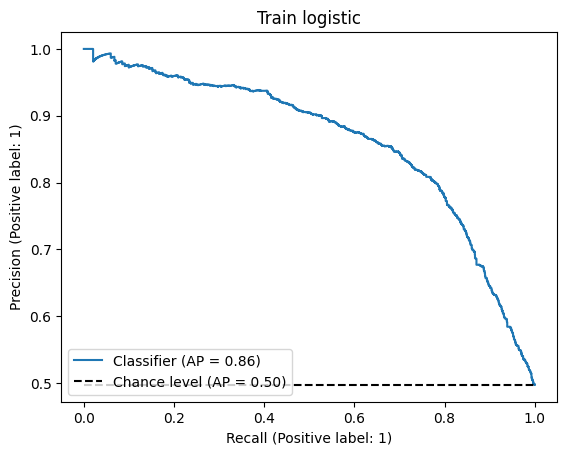

In [64]:
l, s = train['label'], refitted_positional_logit.predict()
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

Average precision: 0.8396851402739494


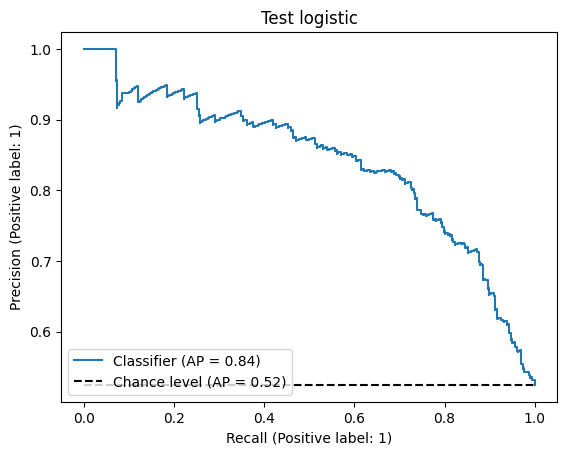

In [65]:
l, s = test['label'], refitted_positional_logit.predict(X_test)
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Test logistic')
print('Average precision:', average_precision_score(l, s))

Manakov validation:

In [63]:
manakov_lo = get_dataset_df(list_datasets()[2], split="leftout")
manakov_lo.describe()

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_eCLIP_Manakov2022/leftout/dataset.tsv


,label,start,end,gene_cluster_ID
count,20054.000000,2.005400e+04,2.005400e+04,20054.000000
mean,0.500000,7.777583e+07,7.777588e+07,4527.216216
std,0.500012,5.656789e+07,5.656789e+07,2574.098725
min,0.000000,4.960000e+02,5.450000e+02,1.000000
25%,0.000000,3.283980e+07,3.283985e+07,2304.000000
50%,0.500000,6.680742e+07,6.680747e+07,4584.500000
75%,1.000000,1.130310e+08,1.130311e+08,6749.000000
max,1.000000,2.473332e+08,2.473333e+08,8808.000000


In [64]:
manakov_lo_len_select = [len(s)==22 for s in manakov_lo['noncodingRNA']]
manakov_lo = manakov_lo.loc[manakov_lo_len_select]

In [65]:
alignments_manakov_lo = get_posaware_alignments(manakov_lo, M, G_miR, G_gene)

In [66]:
scores_manakov = np.array([x[0] for x in alignments_manakov_lo])
probs_manakov = logit_lhood_vect(scores_manakov, alpha)

Average precision: 0.7974947531493604


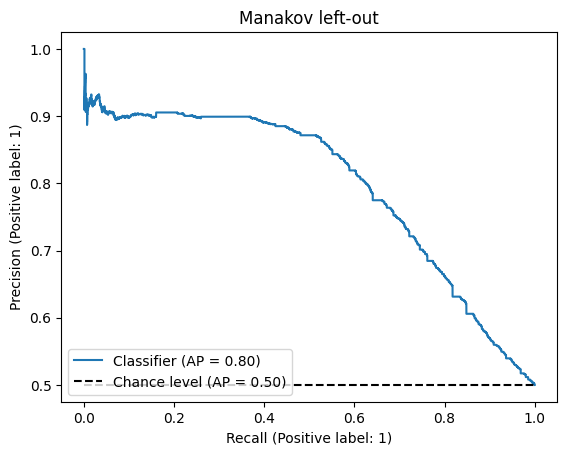

In [67]:
l, s = manakov_lo['label'], probs_manakov
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Manakov left-out')
print('Average precision:', average_precision_score(l, s))

Text(0.5, 1.0, 'Scores on Manakov left-out')

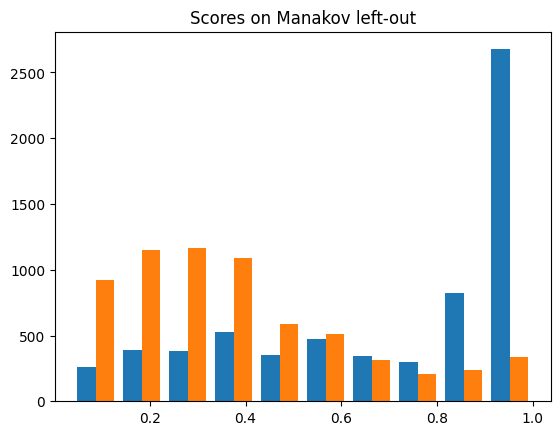

In [68]:
plt.figure()
plt.hist([probs_manakov[manakov_lo['label']==1], probs_manakov[manakov_lo['label']==0]])
plt.title('Scores on Manakov left-out')